# Optimizing EddyPro Settings


In [3]:
from pathlib import Path
import random

import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import hesseflux

wd = Path("../..")

## Planar Fit Parameters

Fit sectors: E and W

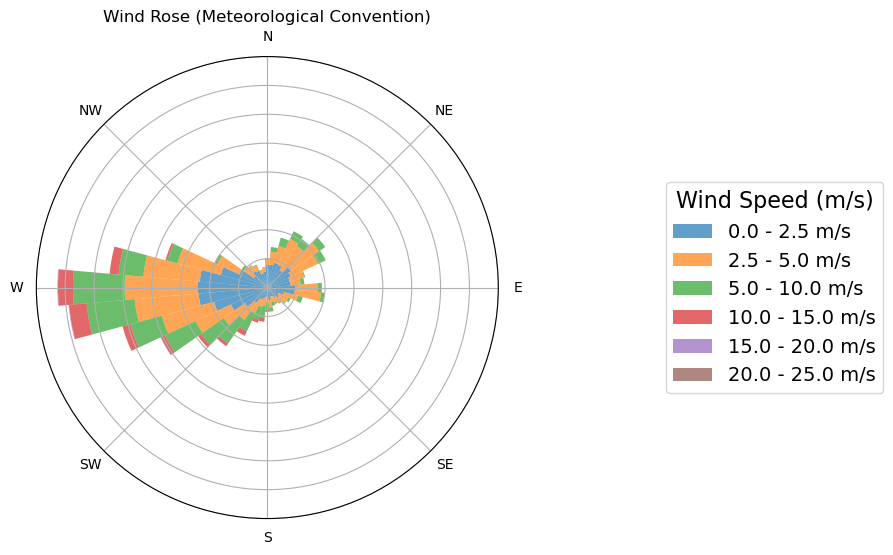

In [15]:
# concatenate all converted files into a single DataFrame, indexed by TIMESTAMP

summary_files = list(wd.glob("L0c_ingested/SlowRaw/*.feather"))
summary_files = random.sample(summary_files, min(len(summary_files), 10))  # 10 random weeks

df = (
    pd.concat(pd.read_feather(f) for f in summary_files)
    .sort_index()
)
df
# plot code below
fig, axs = plt.subplots(1, 2, figsize=(12, 6), width_ratios=[3, 1], subplot_kw={'projection': 'polar'})
wind_ax = axs[0]
res = 5
ws_bin_edges = [0, 2.5, 5, 10, 15, 20, 25]
ws_bins = pd.cut(df["irgason_ws"], bins=ws_bin_edges)
bins = np.arange(0, 370, 10)
bottom = 0
for ws_bin, group in df.groupby(ws_bins, observed=False):
    hist = np.histogram(group["irgason_wd"], bins=bins, range=(0, 360))[0]
    wind_ax.bar(
        np.deg2rad(bins[:-1]),
        hist,
        bottom=bottom,
        width=np.deg2rad(10),
        label=f"{ws_bin.left:.1f} - {ws_bin.right:.1f} m/s",
        alpha=0.7,
    )
    bottom += hist
wind_ax.set_theta_zero_location("N")
wind_ax.set_theta_direction(-1)
wind_ax.set_title("Wind Rose (Meteorological Convention)")
wind_ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
wind_ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
wind_ax.set_yticks(wind_ax.get_yticks())
wind_ax.set_yticklabels([""]*len(wind_ax.get_yticks()))

legend_ax = axs[1]
legend_ax.axis("off")
handles, labels = wind_ax.get_legend_handles_labels()
legend_ax.legend(
    handles,
    labels,
    title="Wind Speed (m/s)",
    loc="center",
    bbox_to_anchor=(0.5, 0.5),
    fontsize=14,
    title_fontsize=16,
);

To identify the thresholds for horizontal and vertical windspeed, we will run several planar fits on the data, each time applying a different threshold for the vertical windspeed. We will then look at the resulting fit parameters to identify at what threshold the fit parameters stabilize.

Text(0, 0.5, 'Min U (m/s)')

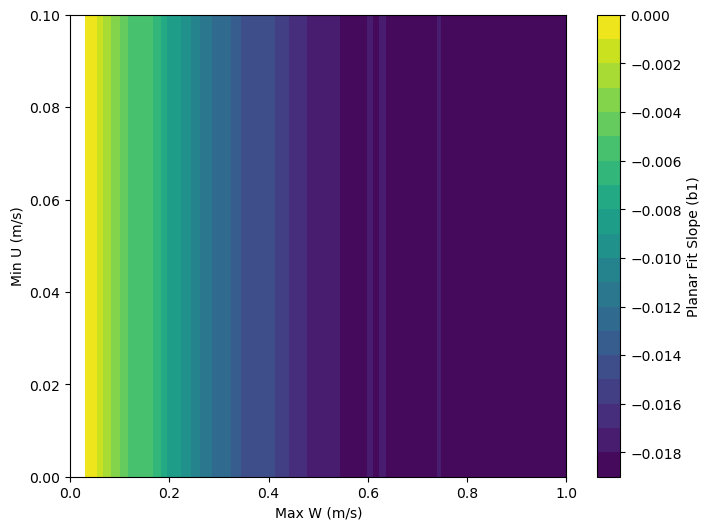

In [70]:
import statsmodels.api as sm
from typing import Callable
import numpy as np

class PlanarFitRotation:
    """
    Class for performing planar fit rotation on 3D velocity data.
    See Wilczak et al. (2001) for details.
    """
    def __init__(self):
        self._rotation: Callable | None = None
    def compute(self, ubar: np.ndarray, vbar: np.ndarray, wbar: np.ndarray) -> None:
        """
        Compute the rotation matrix from the mean velocities.

        Parameters
        ----------
        ubar : np.ndarray
            Mean velocity in the x-direction. Shape (N,), where N is the number of flux periods.
        vbar : np.ndarray
            Mean velocity in the y-direction. Shape (N,).
        wbar : np.ndarray
            Mean velocity in the z-direction. Shape (N,).
        """
        
        # compute the plane of the local streamlines to yield a rotation matrix to apply to all the data
        b0, b1, b2 = sm.OLS(wbar, sm.add_constant(np.stack((ubar, vbar), axis=1))).fit().params
        
        aux1 = np.sqrt(1.0 + b1**2 + b2**2)
        aux2 = np.sqrt(1.0 + b2**2)

        M_pf = np.array([
            [ aux2 / aux1,           -b1*b2 / (aux1*aux2),   b1 / (aux1*aux2)],
            [ 0.0,                    1.0 / aux2,            b2 / aux2],
            [-b1 / aux1,             -b2 / aux1,             1.0 / aux1],
        ], dtype=float)

        def _rotation(u: np.ndarray, v: np.ndarray, w: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
            """
            Function to apply the planar fit rotation to high-frequency data.
            """
            # 3x3 @ 3xN -> 3xN
            # TODO: check??
            u_pf, v_pf, w_pf = M_pf @ np.stack((u, v, w), axis=0)
            
            theta = np.arctan2(v_pf, u_pf)
            costheta = np.cos(theta)
            sintheta = np.sin(theta)
            u_rot = u_pf*costheta + v_pf*sintheta
            v_rot = -u_pf*sintheta + v_pf*costheta
            w_rot = w_pf

            return u_rot, v_rot, w_rot
        self._rotation = _rotation

        return b1, b2

    def rotate(self, u: np.ndarray, v: np.ndarray, w: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Apply the planar fit rotation to high-frequency data.
        """
        if self._rotation is None:
            raise ValueError("Rotation not computed yet. Call compute() first.")
        return self._rotation(u, v, w)
    
summary = (
    pd.concat(pd.read_feather(f) for f in wd.glob("L0c_ingested/SlowStats/*.feather"))
    .sort_index()
    .dropna(subset=["ux_Avg", "uy_Avg", "uz_Avg"])
)

PlanarFit = PlanarFitRotation()
summary

nx, ny = 101, 4
max_w = np.linspace(0, 1, nx)
min_u = np.linspace(0, 0.1, ny)

MAXW, MINU = np.meshgrid(max_w, min_u)
MAXW, MINU = MAXW.flatten(), MINU.flatten()
b2s = []
b1s = []
nums = []
for mxw, mnu in zip(MAXW, MINU):
    tmp = summary.query("uz_Avg <= @mxw and irgason_ws_Avg >= @mnu and uz_Avg >= -@mxw")
    try:
        b1, b2 = PlanarFit.compute(tmp["ux_Avg"].values, tmp["uy_Avg"].values, tmp["uz_Avg"].values)
    except ValueError:
        b1, b2 = np.nan, np.nan
    b1s.append(b1)
    b2s.append(b2)

    nums.append(len(tmp))
b1s = np.array(b1s)
b2s = np.array(b2s)

nums = np.array(nums)
b1s = np.where(nums < 250, np.nan, b1s)  # mask out bins with too few samples
b2s = np.where(nums < 250, np.nan, b2s)  # mask out bins with too few samples
MAXW, MINU = MAXW.reshape(ny, nx), MINU.reshape(ny, nx)
b2s = np.array(b2s).reshape(ny, nx)
b1s = np.array(b1s).reshape(ny, nx)
nums = np.array(nums).reshape(ny, nx)

b2s_gradient = np.gradient(b2s, np.diff(max_w)[0], np.diff(min_u)[0], edge_order=2)
plt.figure(figsize=(8, 6))
# plt.pcolormesh(MAXW, MINU, (b2s_gradient[1]))
plt.contourf(MAXW, MINU, b1s, levels=20, cmap="viridis")
plt.colorbar(label="Planar Fit Slope (b1)")
plt.xlabel("Max W (m/s)")
plt.ylabel("Min U (m/s)")

Planar fit seems relatively insensitive to Min U: we can choose an optimistic value of 0.5 m/s. However, it is quite sensitive to Max W: b2 steadily increases as Max W increases, then stabilizes around 0.5m/s. We will choose a Max W threshold of 0.5 m/s. Allowing in values > 0.5m/s seems increase noise in the fit parameters.

Minimum mean horizontal wind component

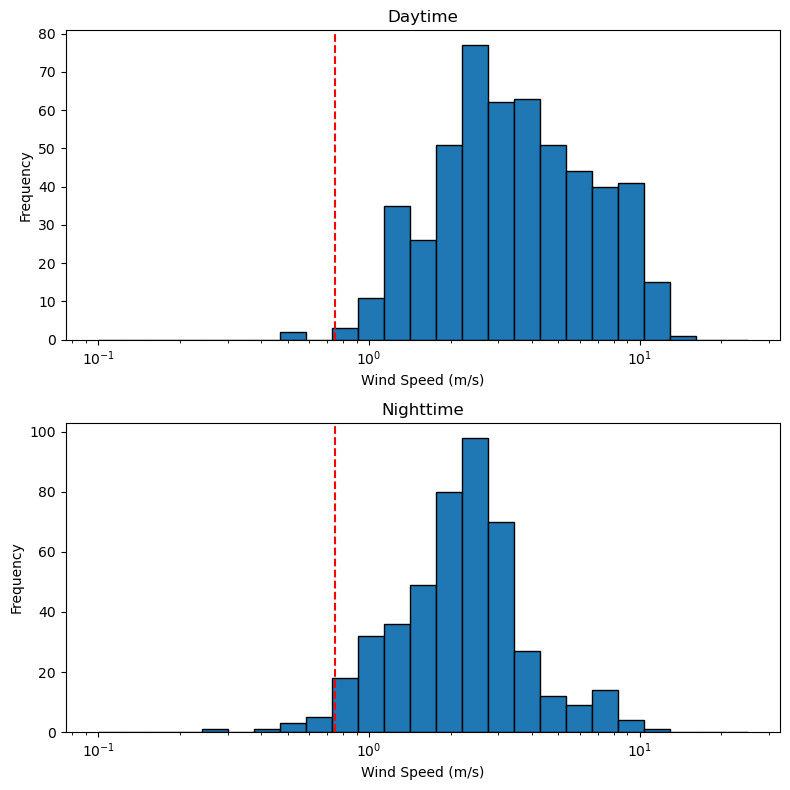

In [33]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8))
axs[0].hist(df.query("sw_in_Avg > 5")["irgason_ws_Avg"], bins=np.logspace(-1, np.log10(25), 26), edgecolor="black")
axs[1].hist(df.query("sw_in_Avg <= 5")["irgason_ws_Avg"], bins=np.logspace(-1, np.log10(25), 26), edgecolor="black")
axs[0].set_xscale("log")
axs[1].set_xscale("log")
axs[0].set_xlabel("Wind Speed (m/s)")
axs[0].set_ylabel("Frequency")
axs[0].set_title("Daytime")
axs[1].set_xlabel("Wind Speed (m/s)")
axs[1].set_ylabel("Frequency")
axs[1].set_title("Nighttime")

for ax in axs:
    ax.axvline(0.75, color="red", linestyle="--")
fig.tight_layout()
plt.show()

Maximum mean vertical wind component

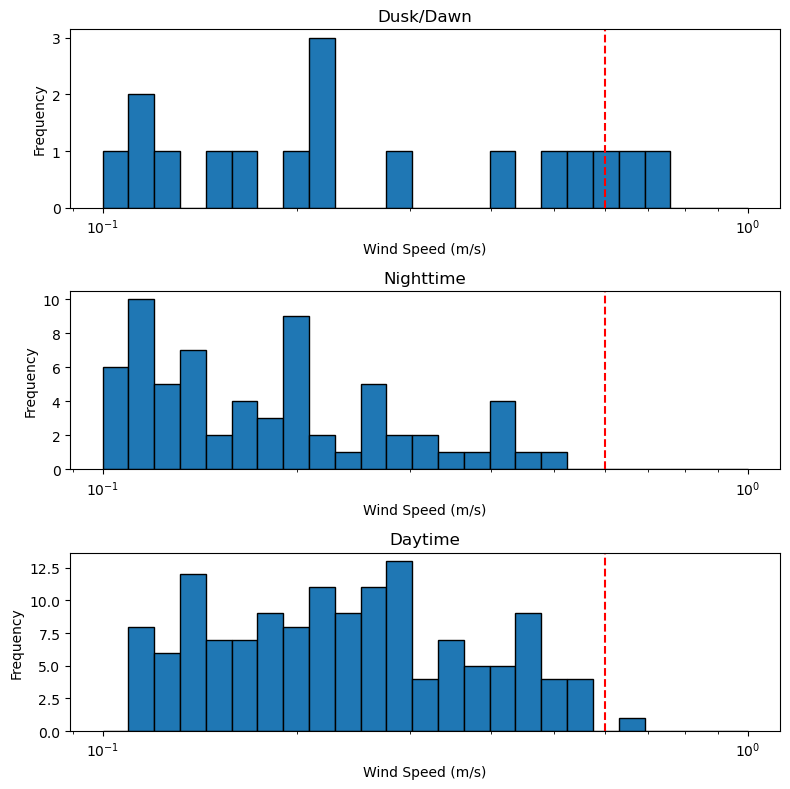

In [55]:
fig, axs = plt.subplots(3, 1, figsize=(8, 8))
axs[0].hist(df.query("sw_in_Avg < 100 and sw_in_Avg > 5")["uz_Avg"], bins=np.logspace(-1, np.log10(1), 26), edgecolor="black")
axs[1].hist(df.query("sw_in_Avg <= 1")["uz_Avg"], bins=np.logspace(-1, np.log10(1), 26), edgecolor="black")
axs[2].hist(df.query("sw_in_Avg > 400")["uz_Avg"], bins=np.logspace(-1, np.log10(1), 26), edgecolor="black")
axs[0].set_xscale("log")
axs[1].set_xscale("log")
axs[2].set_xscale("log")
axs[0].set_xlabel("Wind Speed (m/s)")
axs[0].set_ylabel("Frequency")
axs[0].set_title("Dusk/Dawn")
axs[1].set_xlabel("Wind Speed (m/s)")
axs[1].set_ylabel("Frequency")
axs[1].set_title("Nighttime")
axs[2].set_xlabel("Wind Speed (m/s)")
axs[2].set_ylabel("Frequency")
axs[2].set_title("Daytime")

for ax in axs:
    ax.axvline(0.6, color="red", linestyle="--")
fig.tight_layout()
plt.show()

Double-checking planar fit calculation

In [67]:
with open(wd / "L2_eddypro_outputs/wrtbi-main/eddypro_run1_planar_fit_2026-05-28T145751_adv.txt", "r") as pff:
    for _ in range(14): 
        pff.readline()
    sector_1_header = pff.readline().strip()
    sector_1_numerosity = int(sector_1_header.split(":")[-1].strip())
    for _ in range(3):
        pff.readline()
    sector_2_header = pff.readline().strip()
    sector_2_numerosity = int(sector_2_header.split(":")[-1].strip())
print(sector_1_numerosity, sector_2_numerosity)
sector_1_obs, sector_2_obs = df.query("irgason_wd_Avg < 180 and irgason_ws_Avg >= 0.75 and uz_Avg <= 0.6").shape[0], df.query("irgason_wd_Avg >= 180  and irgason_ws_Avg >= 0.75 and uz_Avg <= 0.6").shape[0]

print("Sector Numerosity Ratio (N1/N2):")
print("\tEddyPro:", sector_1_numerosity / sector_2_numerosity)
print("\tObserved:", sector_1_obs / sector_2_obs)

318 735
Sector Numerosity Ratio (N1/N2):
	EddyPro: 0.4326530612244898
	Observed: 0.5651465798045603


# Testing Some QA/QC procedures

In [3]:
fullout_file = wd / "L2_eddypro_outputs/wrtbi-main/eddypro_run1_full_output_2026-05-28T164840_adv.csv"
fullout = pd.read_csv(fullout_file, skiprows=[0, 2], na_values=["-9999.00", "-9999"])
with open(fullout_file, "r") as f:
    f.readline()
    f.readline()
    units = f.readline().strip().split(",")
    units = {c:u.strip('[]') for c, u in zip(fullout.columns, units)}
fullout["TIMESTAMP"] = pd.to_datetime(fullout["date"] + " " + fullout["time"])
fullout = fullout.set_index("TIMESTAMP").sort_index()

# 0 = best, 1 = aggregate, 2 = bad
fullout["H"] = np.where(fullout["qc_H"] < 2, fullout["H"], np.nan)
fullout["LE"] = np.where(fullout["qc_LE"] < 2, fullout["LE"], np.nan)
fullout["ET"] = np.where(fullout["qc_LE"] < 2, fullout["ET"], np.nan)
fullout["co2_flux"] = np.where(fullout["qc_co2_flux"] < 2, fullout["co2_flux"], np.nan)
fullout["h2o_flux"] = np.where(fullout["qc_h2o_flux"] < 2, fullout["h2o_flux"], np.nan)
fullout["Tau"] = np.where(fullout["qc_Tau"] < 2, fullout["Tau"], np.nan)
fullout["u*"] = np.where(fullout["qc_Tau"] < 2, fullout["u*"], np.nan)

## U* Filter (manual vs hesseflux)

0.12431151171199321


(0.0, 0.5)

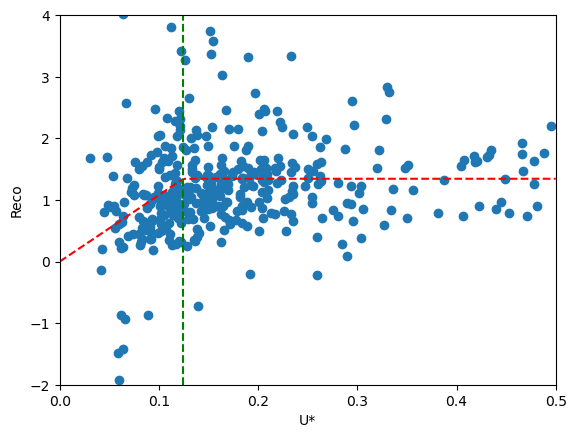

In [21]:
def broken_stick_function(x, b0, b1, b2, tau):
    return np.where(x <= tau, b0 + b1 * x, b0 + b1 * x + (b2 - b1) * (x - tau))

def fit_broken_stick(x, y):
    from scipy.optimize import curve_fit
    popt, _ = curve_fit(lambda x, b1, tau: broken_stick_function(x, 0, b1, 0, tau), x, y, p0 = [8, 0.2])
    return popt

b1_opt, tau_opt = fit_broken_stick(*fullout.query("daytime == 0 and co2_flux > 0 and co2_flux < 3")[["u*", "co2_flux"]].dropna().values.T)
print(tau_opt)

plt.scatter(fullout.query("daytime == 0")["u*"], fullout.query("daytime == 0")["co2_flux"])
x = np.linspace(0, 0.5, 100)
plt.plot(x, broken_stick_function(x, b0=0, b1=b1_opt, b2=0, tau=tau_opt), color="red", linestyle="--", label="Example Broken Stick Fit")
plt.axvline(tau_opt, color="green", linestyle="--", label=f"Estimated u* Threshold: {tau_opt:.2f} m/s")
plt.xlabel("U*")
plt.ylabel("Reco")
plt.ylim(-2, 4)
plt.xlim(0, 0.5)

In [ ]:
hesseflux_df = (
    fullout
    [["u*", "co2_flux", "air_temperature"]]
    .rename(columns={"u*":"USTAR", "co2_flux":"NEE", "air_temperature":"TA"})
    .assign(
        TA = lambda df: df["TA"] - 273.15,
    )
)

hesseflux_flag = (
    fullout[["qc_co2_flux", "qc_Tau"]]
    .rename(columns={"qc_co2_flux":"NEE", "qc_Tau":"USTAR"})
)
hesseflux_flag["TA"] = 0  # no TA flag, so just add a dummy one with all good values
hesseflux_flag = hesseflux_flag

hesseflux_isday = fullout[["daytime"]].rename(columns={"daytime":"isday"}).astype(bool)



_, ustar_flag = hesseflux.ustarfilter(
    hesseflux_df, 
    isday=hesseflux_isday,
    flag=hesseflux_flag,
    nboot=20,
    nmon=3,
    randomstate=8472,
    mindaysperyear=360,
    minseasondata=100,
    seasonout=True,
    ustardefault=0.2
)

ustar_flag = ustar_flag.astype(bool)

fullout[["LE_ustar", "H_ustar", "ET_ustar", "co2_flux_ustar", "h2o_flux_ustar"]] = fullout[["LE", "H", "ET", "co2_flux", "h2o_flux"]].copy()
fullout.loc[ustar_flag, ["LE_ustar", "H_ustar", "ET_ustar", "co2_flux_ustar", "h2o_flux_ustar"]] = np.nan

# update hesseflux_flag to include ustar_flag
hesseflux_flag = (hesseflux_flag.astype(bool) | ustar_flag.values.reshape(-1, 1)).astype(int)




/Users/alex/mambaforge/envs/python3.11/lib/python3.11/site-packages/hesseflux/ustarfilter.py:309: UserWarning: Dataset averages < 360 days of data per year (got 26). ustarfilter is designed for datasets with at least one full year of data. Results may be unreliable.
  warnings.warn(msg)
/Users/alex/mambaforge/envs/python3.11/lib/python3.11/site-packages/hesseflux/ustarfilter.py:361: UserWarning: Not enough data for year 2026, season 0 to estimate ustar (got 27, need 100). Ustar threshold for this season will be set to ustardefault, or the maximum of other seasons if ustardefault is None.
  warnings.warn(msg)


ValueError: Array conditional must be same shape as self

# Final outputs: results of QA/QC on flux computations plus the preprocessed biomet data